In [425]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

myseed=0
np.random.seed(myseed)

# 1. Representation of the dataset 

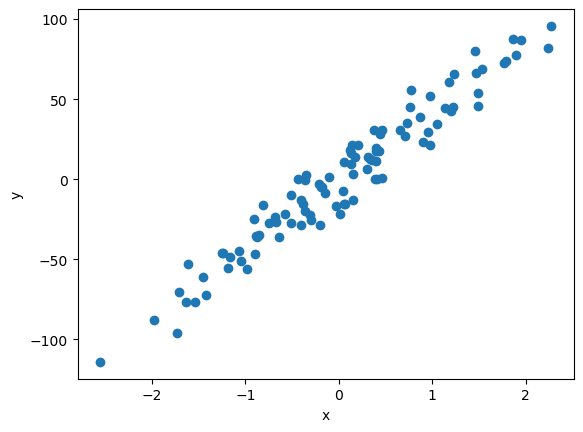

In [426]:
# Creation of a dataset
x, y = make_regression(n_samples=100, n_features=1, noise=10)

# Visualization of the dataset
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# 2. Matrices X, Y and $\theta$

In [427]:
# X matrix of dim m,(n+1)

X = np.hstack((x, np.ones(x.shape)))
print("Shape of X:", X.shape)
X

Shape of X: (100, 2)


array([[-0.35955316,  1.        ],
       [ 0.97663904,  1.        ],
       [ 0.40234164,  1.        ],
       [-0.81314628,  1.        ],
       [-0.88778575,  1.        ],
       [ 0.44386323,  1.        ],
       [-0.97727788,  1.        ],
       [ 0.42833187,  1.        ],
       [ 0.20827498,  1.        ],
       [-0.31155253,  1.        ],
       [-0.51080514,  1.        ],
       [ 0.12691209,  1.        ],
       [-1.53624369,  1.        ],
       [-0.40178094,  1.        ],
       [ 0.6536186 ,  1.        ],
       [ 1.17877957,  1.        ],
       [-0.17992484,  1.        ],
       [ 1.78587049,  1.        ],
       [ 1.45427351,  1.        ],
       [-0.68481009,  1.        ],
       [ 0.97873798,  1.        ],
       [ 1.89588918,  1.        ],
       [-0.4380743 ,  1.        ],
       [ 0.3130677 ,  1.        ],
       [ 0.76103773,  1.        ],
       [ 0.77749036,  1.        ],
       [ 1.9507754 ,  1.        ],
       [ 0.33367433,  1.        ],
       [-0.34791215,

In [428]:
# Y matrix of dim m,n

Y = y.reshape(y.shape[0], 1)
print("Shape of Y:", Y.shape)
Y

Shape of Y: (100, 1)


array([[-1.99558856e+01],
       [ 2.13397727e+01],
       [ 1.15568946e+01],
       [-1.63420692e+01],
       [-3.57006385e+01],
       [ 2.79953955e+01],
       [-5.63235304e+01],
       [ 1.76104141e+01],
       [ 2.14510620e+01],
       [-2.23528647e+01],
       [-2.74674636e+01],
       [ 9.30231368e+00],
       [-7.64902562e+01],
       [-2.83346523e+01],
       [ 3.06916745e+01],
       [ 6.04429895e+01],
       [-5.12662959e+00],
       [ 7.38599937e+01],
       [ 8.02758700e+01],
       [-2.38147640e+01],
       [ 5.17924631e+01],
       [ 7.74719877e+01],
       [ 2.65538141e-01],
       [ 1.41668399e+01],
       [ 4.51707474e+01],
       [ 5.57976548e+01],
       [ 8.68235998e+01],
       [ 1.25549501e+01],
       [ 2.65610251e+00],
       [ 6.85718935e+01],
       [-4.67284355e+01],
       [-2.19181505e+01],
       [-5.10544891e+01],
       [ 3.04769664e+01],
       [-2.17385589e+01],
       [ 3.07746441e+01],
       [ 2.13476276e+01],
       [-1.30570016e+01],
       [-1.5

In [429]:
# Initialization of a random theta vector of dim (n+1),1

theta = np.random.randn(2, 1)
print("Shape of theta:", theta.shape)
theta

Shape of theta: (2, 1)


array([[-0.63743703],
       [-0.39727181]])

# 2. Model implementation

In [430]:
def model(X, theta):
    """
    Function representing the linear regression model F = X * theta.
    
    Args:
    X (numpy.ndarray): The input feature matrix of shape (m, n+1), where m is the number of data points and n is the number of features.
    theta (numpy.ndarray): The parameter vector of shape (n, 1), representing the weights for the features.
    
    Returns:
    numpy.ndarray: The output prediction vector F of shape (m, 1).
    """
    return X.dot(theta)

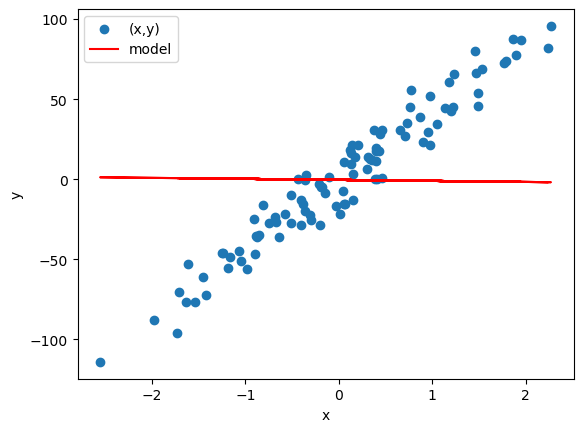

In [431]:
# Plot of non optimized linear regression on the dataset (x,y)

plt.scatter(x, y, label='(x,y)')
plt.plot(x, model(X, theta), c='r', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [432]:
def cost_function(X, y, theta):
    """
    Function to compute the Mean Squared Error (MSE) cost function for linear regression.
    
    The cost function is defined as:
    J(theta) = (1 / (2 * m)) * Σ (X * theta - Y)^2
    
    Args:
    X (numpy.ndarray): The input feature matrix of shape (m, n), where m is the number of data points and n is the number of features.
    y (numpy.ndarray): The target vector of shape (m, 1), representing the true values.
    theta (numpy.ndarray): The parameter vector of shape (n, 1), representing the weights for the features.
    
    Returns:
    float: The computed cost (MSE) value.
    """
    # Number of training examples
    m = len(y)

    # Mean Squared Error cost
    cost = (1 / (2 * m)) * np.sum((model(X, theta) - y)**2)
    
    return cost

In [433]:
cost_function(X,y,theta)

98222.87798667629

# 3. Calcul of the gradient

In [434]:
def grad(X, Y, theta):
    """
    Function to compute the gradient of the cost function J(theta) with respect to the parameters theta.
    
    The gradient is defined as:
    grad(J(theta)) = (1 / m) * X^T * (X * theta - Y)
    
    Args:
    X (numpy.ndarray): The input feature matrix of shape (m, n), where m is the number of data points and n is the number of features.
    y (numpy.ndarray): The target vector of shape (m, 1), representing the true values.
    theta (numpy.ndarray): The parameter vector of shape (n, 1), representing the weights for the features.
    
    Returns:
    numpy.ndarray: The computed gradient vector of shape (n, 1).
    """
    # Number of training examples
    m = len(Y)
    # Gradient of the cost function
    gradient = (1 / m) * X.T.dot(model(X, theta) - Y)

    return gradient


# 4. Gradient descent algorithm

In [435]:
def gradient_descent(X, Y, theta, learning_rate, n_iterations):
    """
    Function to perform gradient descent optimization for linear regression, 
    updating the parameter vector theta iteratively and storing the cost at each iteration.
    
    The update rule for theta is:
    theta = theta - learning_rate * grad(X, y, theta)
    
    Args:
    X (numpy.ndarray): The input feature matrix of shape (m, n), where m is the number of data points and n is the number of features.
    y (numpy.ndarray): The target vector of shape (m, 1), representing the true values.
    theta (numpy.ndarray): The initial parameter vector of shape (n, 1), representing the weights for the features.
    learning_rate (float): The learning rate (step size) for each iteration of gradient descent.
    n_iterations (int): The number of iterations to perform.
    
    Returns:
    numpy.ndarray: The optimized parameter vector theta after performing gradient descent.
    numpy.ndarray: A history of cost values for each iteration of gradient descent.
    """
    # Initialize cost history to track the cost at each iteration
    cost_history = np.zeros(n_iterations)
    
    # Iterative process of gradient descent
    for i in range(0, n_iterations):
        # Update the parameter vector theta using the gradient
        theta = theta - learning_rate * grad(X, Y, theta) 
        
        # Calculate and store the cost for the current iteration
        cost_history[i] = cost_function(X, Y, theta)
        
    return theta, cost_history

# 5. Training and optimization

In [436]:
n_iterations=1000
learning_rate=0.001
theta_final, cost_history = gradient_descent(X, Y, theta, learning_rate=learning_rate, n_iterations=n_iterations)

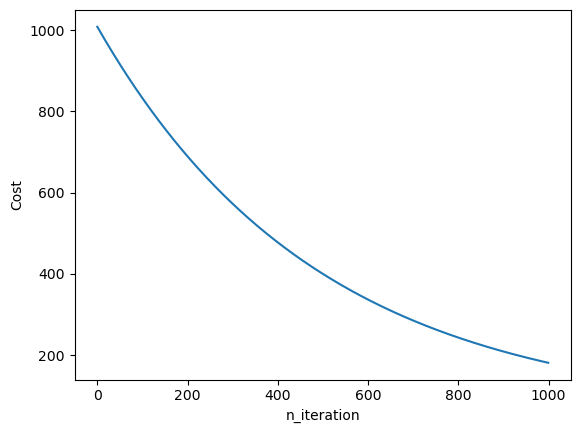

In [437]:
plt.plot(range(n_iterations), cost_history)
plt.xlabel("n_iteration")
plt.ylabel("Cost")
plt.show()

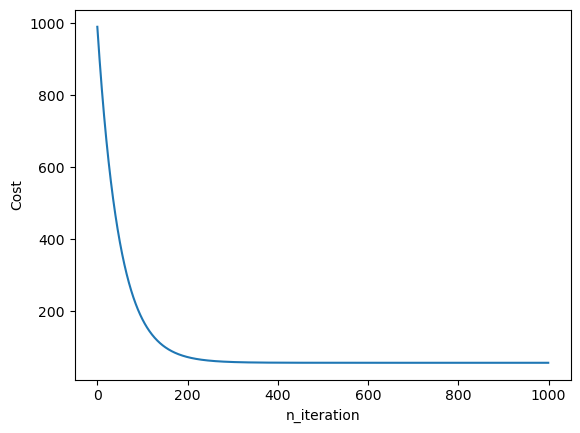

In [438]:
# Increase learnign rate

n_iterations=1000
learning_rate=0.01
theta_final, cost_history = gradient_descent(X, Y, theta, learning_rate=learning_rate, n_iterations=n_iterations)
plt.plot(range(n_iterations), cost_history)
plt.xlabel("n_iteration")
plt.ylabel("Cost")
plt.show()

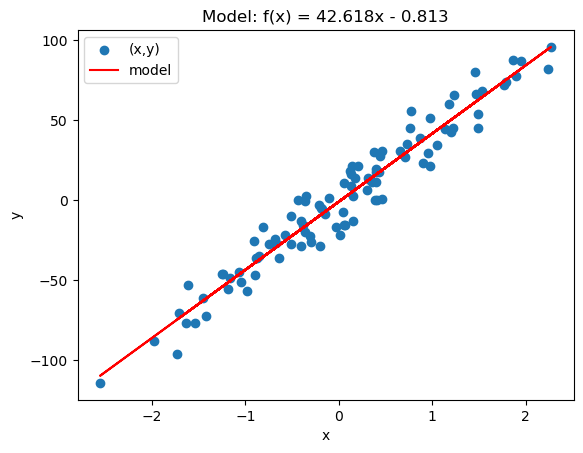

In [439]:
# Calcul of y_pred
predictions = model(X, theta_final)

sign = '+' if theta_final[1][0] >= 0 else '-'


# Plot the results
plt.scatter(x, y, label='(x,y)')
plt.plot(x, predictions, c='r', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f"Model: f(x) = {theta_final[0][0]:.3f}x {sign} {abs(theta_final[1][0]):.3f}")
plt.show()

In [440]:
theta_final

array([[42.61757635],
       [-0.81307283]])

# 6. Metric of performance

In [441]:
def coef_determination(Y, pred):
    """
    Function to compute the R² (coefficient of determination) score, which measures 
    the proportion of variance in the dependent variable that is predictable from the independent variable(s).
    
    The R² score is defined as:
    R² = 1 - (sum of squared residuals / total sum of squares)
    
    Args:
    y (numpy.ndarray): The true target values of shape (m, 1).
    pred (numpy.ndarray): The predicted values from the model of shape (m, 1).
    
    Returns:
    float: The R² score, a measure of how well the model explains the variance in the target values.
    """
    # Residual sum of squares (RSS)
    u = np.sum((Y - pred)**2)
    
    # Total sum of squares (TSS)
    v = np.sum((Y - Y.mean())**2)
    
    # Calculate and return the R² score
    return 1 - u / v


In [442]:
predictions = model(X, theta_final)
coef_determination(Y, predictions)

0.9417294704806692

# 7. Comparison with scikit learn

R²: 0.9417294727711081


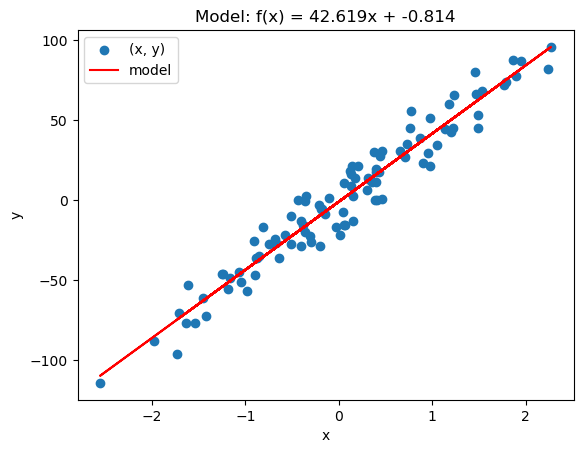

In [443]:
# Initialize the linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(x, y)

# Get the model parameters (slope and intercept)
theta_0 = model.intercept_
theta_1 = model.coef_[0]

# Predict using the model
predictions = model.predict(x)

print("R²:", model.score(x, y))

# Plot the results
plt.scatter(x, y, label='(x, y)')
plt.plot(x, predictions, c='r', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f"Model: f(x) = {theta_1:.3f}x + {theta_0:.3f}")
plt.show()
